In [109]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os,sys
import warnings
from xrsana import math_functions
from scipy.optimize import curve_fit
from xrsana import extract_compton_platform 

In [110]:
PROJECT_ROOT = "/home/hushiqi/work/xrs_ana"
SCAN_NAME = "Ho_Comptonscan"
DATA_PATH = os.path.join(PROJECT_ROOT, "ex_space", "analysis", "data", SCAN_NAME)
RESULT_PATH = os.path.join(PROJECT_ROOT, "ex_space", "analysis", "result")
RESULT_DIR = os.path.join(RESULT_PATH, SCAN_NAME)
SQW_PATH = os.path.join(RESULT_DIR, "result.dat")
os.makedirs(RESULT_DIR, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-xrsana")
warnings.filterwarnings("ignore", category=RuntimeWarning)

sys.path.insert(0, PROJECT_ROOT)

from xrsana import xrs_extraction, xrs_read

Loading HEPS ID33 reduced data : /home/hushiqi/work/xrs_ana/ex_space/analysis/data/Ho_Comptonscan

Reader summary
scan_name       : Ho_Comptonscan
E0 (keV)        : 9.683032643850813
q average       : 9.58704206984813
tth (deg)       : [155.2971955488892]
eloss shape     : (4001,)
signals shape   : (4001, 1)
errors shape    : (4001, 1)
selected ROIs   : 12
analyzer key    : {'Analyzer01': 0}
average signal  : (4001,)
average error   : (4001,)
average q head  : [5.07352433 5.07352433 5.07352433 5.07352433 5.07352433]


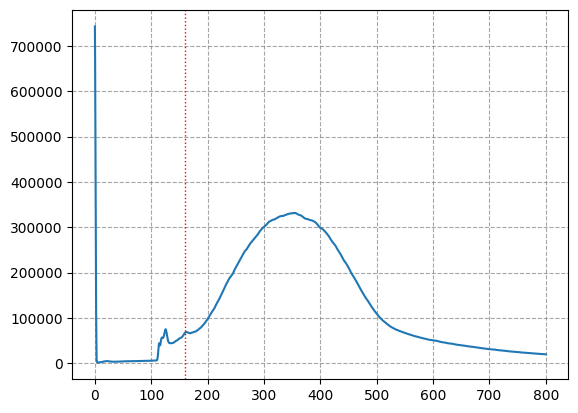

In [111]:
print("Loading HEPS ID33 reduced data :", DATA_PATH)
data = xrs_read.read_heps_id33(DATA_PATH)

print("\nReader summary")
print("scan_name       :", data.scan_name)
print("E0 (keV)        :", data.E0)
print("q average       :", data.q_average)
print("tth (deg)       :", data.tth)
print("eloss shape     :", data.eloss.shape)
print("signals shape   :", data.signals.shape)
print("errors shape    :", data.errors.shape)
print("selected ROIs   :", len(data.selected_rois))
print("analyzer key    :", data.key)
data_ex = xrs_extraction.edge_extraction(data, ["Ho"], [1.0], {"Ho": ["N5"]})
data_ex.analyzerAverage([0], errorweighing=True)
print("average signal  :", data_ex.avsignals.shape)
print("average error   :", data_ex.averrors.shape)
print("average q head  :", data_ex.avqvals[:5])

plt.plot(data.eloss, data.signals)
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.axvline(x=160, color='red', linestyle=':', linewidth=1)
plt.show()

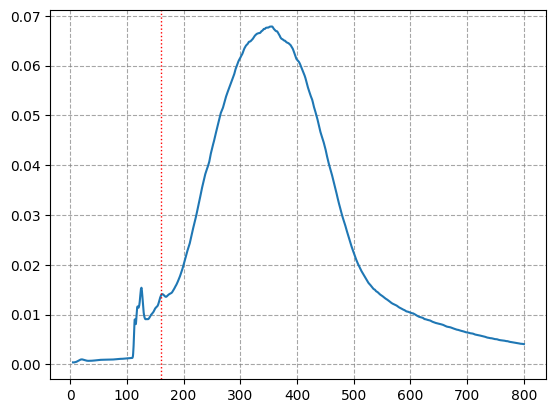

In [112]:
data_ex = xrs_extraction.edge_extraction(data,['Ho'],[1.0],{'Ho':['N4','N5']})
data_ex_cut = data_ex.truncate(5,800, copy_obj=True)
plt.plot(data_ex_cut.eloss, data_ex_cut.signals)
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.axvline(x=160, color='red', linestyle=':', linewidth=1)
plt.show()

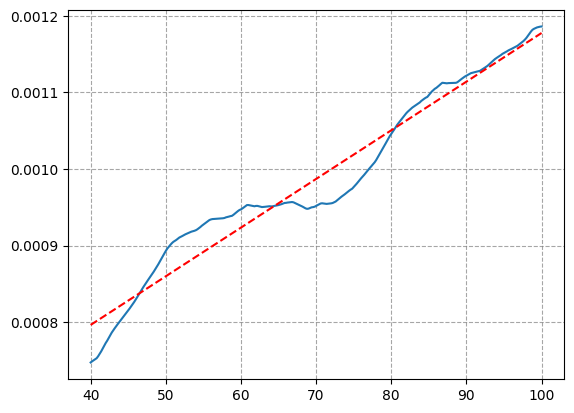

In [113]:
min_eloss = 40
max_eloss = 100
mask = (data_ex_cut.eloss >= min_eloss) & (data_ex_cut.eloss <= max_eloss)

k, b = np.polyfit(data_ex_cut.eloss[mask], data_ex_cut.signals[mask, 0], deg=1)
#first step remove
stray_background = k * data_ex_cut.eloss[mask] + b
plt.plot(data_ex_cut.eloss[mask], data_ex_cut.signals[mask, 0])  
plt.plot(data_ex_cut.eloss[mask], stray_background, color='red', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.show()

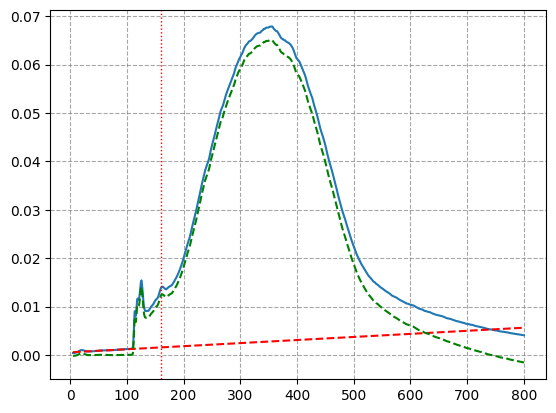

In [114]:
plt.plot(data_ex_cut.eloss, data_ex_cut.signals)
stray_background = k * data_ex_cut.eloss + b
plt.plot(data_ex_cut.eloss, stray_background, color='red', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.axvline(x=160, color='red', linestyle=':', linewidth=1)
data_ex_removestray = data_ex_cut.signals[:, 0] - (k * data_ex_cut.eloss + b)
plt.plot(data_ex_cut.eloss, data_ex_removestray, color='green', linestyle='--')
data_ex_cut.signals[:, 0] = data_ex_removestray
plt.show()


In [115]:
#Sample self-absorption and absorption of the incident X-ray beam between the incident flux monitor and the sample were corrected for.


In [116]:
#HF_data = extract_compton_platform.extract_compton_platform(data_ex_cut.eloss,
#                                                            data_ex_cut.signals[:, 0],
#                                                           data.E0,
 ##                                                          ["Ho"], [1],{"Ho": ["N4"]},[200,400],[100,110],[150,170])

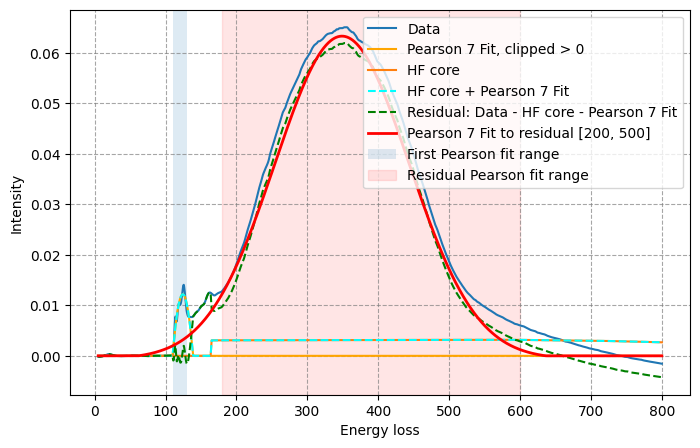

In [117]:
HF_core = extract_compton_platform.get_hf_core(
    eloss=data_ex_cut.eloss,
    E0=data.E0,
    tth=[data.tth[0]],
    formulas=["Ho"],
    stoich_weights=[1.0],
    edges={"Ho": ["N4", "N5"]},
    element="Ho",
    edge="N4",
    normalize=True,
    norm_range=[180,500],
)

p0 = [350, 800, 1, 0.005, 0]

min_eloss = 110
max_eloss = 130

fit_mask = (
    (data_ex_cut.eloss >= min_eloss)
    & (data_ex_cut.eloss <= max_eloss)
)

popt, pcov = curve_fit(
    math_functions.pearson7_forcurvefit,
    data_ex_cut.eloss[fit_mask],
    data_ex_cut.signals[fit_mask, 0],
    p0=p0
)

# Full Pearson peak on the full eloss axis
pearson_peak = math_functions.pearson7(data_ex_cut.eloss, popt)

# Keep array length unchanged, but remove negative part
pearson_peak_pos = np.clip(pearson_peak, 0, None)

# Combined model
model = HF_core + pearson_peak_pos

# Residual
residual = data_ex_cut.signals[:, 0] - model

# =========================
# Pearson fit to residual
# =========================

res_min_eloss = 180
res_max_eloss = 600

res_fit_mask = (
    (data_ex_cut.eloss >= res_min_eloss)
    & (data_ex_cut.eloss <= res_max_eloss)
)

# 初始参数需要按你的 residual 形状调整
# 格式仍然假设是 [amplitude, center, width, shape, offset]
p0_res = [
    np.max(residual[res_fit_mask]),   # amplitude
    data_ex_cut.eloss[res_fit_mask][np.argmax(residual[res_fit_mask])],  # center
    50,                               # width 初值，可调
    0.005,                            # shape 初值，可调
    0                                 # offset
]

popt_res, pcov_res = curve_fit(
    math_functions.pearson7_forcurvefit,
    data_ex_cut.eloss[res_fit_mask],
    residual[res_fit_mask],
    p0=p0_res
)

# Residual Pearson peak on full eloss axis
residual_pearson_peak = math_functions.pearson7(
    data_ex_cut.eloss,
    popt_res
)

# 如果你也想去掉负值
residual_pearson_peak_pos = np.clip(residual_pearson_peak, 0, None)

plt.figure(figsize=(8, 5))

plt.plot(
    data_ex_cut.eloss,
    data_ex_cut.signals[:, 0],
    label="Data"
)

plt.plot(
    data_ex_cut.eloss,
    pearson_peak_pos,
    label="Pearson 7 Fit, clipped > 0",
    color="orange"
)

plt.plot(
    data_ex_cut.eloss,
    HF_core,
    label="HF core"
)

plt.plot(
    data_ex_cut.eloss,
    model,
    label="HF core + Pearson 7 Fit",
    color="cyan",
    linestyle="--"
)

plt.plot(
    data_ex_cut.eloss,
    residual,
    label="Residual: Data - HF core - Pearson 7 Fit",
    color="green",
    linestyle="--"
)

plt.plot(
    data_ex_cut.eloss,
    residual_pearson_peak_pos,
    label="Pearson 7 Fit to residual [200, 500]",
    color="red",
    linewidth=2
)

plt.axvspan(
    min_eloss,
    max_eloss,
    alpha=0.15,
    label="First Pearson fit range"
)

plt.axvspan(
    res_min_eloss,
    res_max_eloss,
    alpha=0.10,
    color="red",
    label="Residual Pearson fit range"
)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.7, color="gray")
plt.xlabel("Energy loss")
plt.ylabel("Intensity")
plt.show()



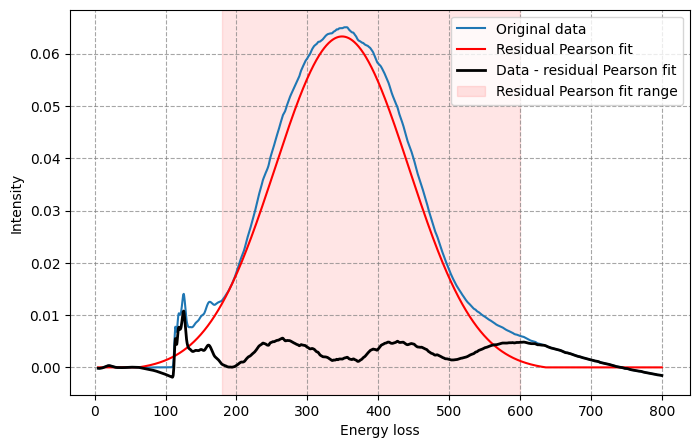

In [118]:
# Data minus fitted residual Pearson peak
data_minus_residual_pearson = (
    data_ex_cut.signals[:, 0] - residual_pearson_peak_pos
)
plt.figure(figsize=(8, 5))

plt.plot(
    data_ex_cut.eloss,
    data_ex_cut.signals[:, 0],
    label="Original data"
)

plt.plot(
    data_ex_cut.eloss,
    residual_pearson_peak_pos,
    label="Residual Pearson fit",
    color="red"
)

plt.plot(
    data_ex_cut.eloss,
    data_minus_residual_pearson,
    label="Data - residual Pearson fit",
    color="black",
    linewidth=2
)

plt.axvspan(
    res_min_eloss,
    res_max_eloss,
    alpha=0.10,
    color="red",
    label="Residual Pearson fit range"
)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.7, color="gray")
plt.xlabel("Energy loss")
plt.ylabel("Intensity")
plt.show()

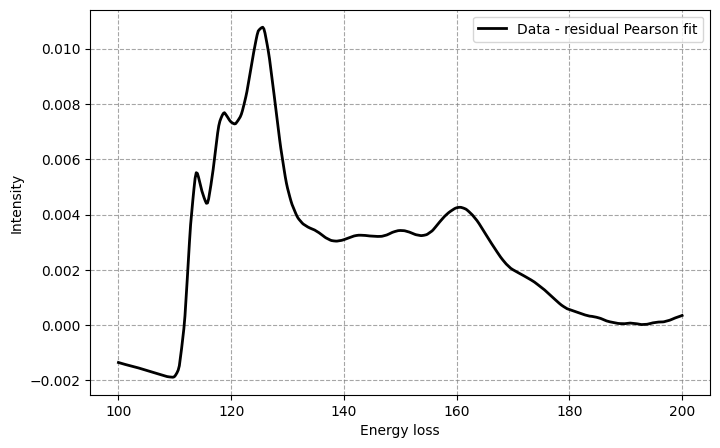

In [119]:
plot_mask = (data_ex_cut.eloss >= 100) & (data_ex_cut.eloss <= 200)

data_minus_residual_pearson = (
    data_ex_cut.signals[:, 0] - residual_pearson_peak_pos
)

plt.figure(figsize=(8, 5))

plt.plot(
    data_ex_cut.eloss[plot_mask],
    data_minus_residual_pearson[plot_mask],
    label="Data - residual Pearson fit",
    color="black",
    linewidth=2
)

plt.grid(True, linestyle="--", alpha=0.7, color="gray")
plt.xlabel("Energy loss")
plt.ylabel("Intensity")
plt.legend()
plt.show()